## Coding Exercise #0301

### 1. Discrete probability distribution:

In [ ]:
import scipy.stats as st
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

#### 1.1. Binomial:

In [ ]:
# Sample size and the p parameter.
n=10
p=0.5

In [ ]:
# Probability distribution at x = 5.
st.binom.pmf(5, n, p)               

In [ ]:
# Quantile at alpha = 0.3
# More about quantiles in the Unit III.
st.binom.ppf(0.3, n, p)             

In [ ]:
# P(0 <= x <= 5)
st.binom.cdf(5,n,p)

In [ ]:
# P(3 <= x <=7)
st.binom.cdf(7,n,p)-st.binom.cdf(2,n,p)        

In [ ]:
# Visualizing the probability distribution.
x=np.arange(0,11)
plt.scatter(x, st.binom.pmf(x,n,p),color='red')
plt.show()

#### 1.2. Poisson:

In [ ]:
# The lambda parameter.
lamb = 2

In [ ]:
# Probability distribution at x = 2.
st.poisson.pmf(2,lamb)             

In [ ]:
# Quantile at alpha = 0.5
# More about quantiles in the Unit III.
st.poisson.ppf(0.5,lamb)                 

In [ ]:
# P(0 <= x <= 5)
st.poisson.cdf(5,lamb)

In [ ]:
# P(3 <= x <=7)
st.poisson.cdf(7,lamb)-st.poisson.cdf(2,lamb)

In [ ]:
# Visualizing the probability distribution.
x=np.arange(0,11)
plt.scatter(x, st.poisson.pmf(x,lamb),color='green')
plt.show()

## Drug User Probability Example

In [20]:
##Example of probability for drug user predictions
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def drug_user(prob_th=0.5, sensitivity = 0.99, specificity = 0.95, prevelance = 0.01,verbose = True):
    # Prior probabilities
    p_user = prevelance            # P(U)
    p_non_user = 1 - p_user        # P(~U)

    # Likelihoods
    p_pos_given_user = sensitivity             # P(+|U)
    p_pos_given_non_user = 1 - specificity     # P(+|~U)

    # Bayes’ theorem: P(U|+) = [P(+|U)*P(U)] / [P(+|U)*P(U) + P(+|~U)*P(~U)]
    numerator = p_pos_given_user * p_user
    denominator = (p_pos_given_user * p_user) + (p_pos_given_non_user * p_non_user)
    prob_posterior = numerator / denominator

    if verbose:
        if prob_posterior >= prob_th:
            print(f"Test Positive: Probability of being a drug user is {prob_posterior:.4f} ≥ {prob_th}")
        else:
            print(f"Test Negative: Probability of being a drug user is {prob_posterior:.4f} < {prob_th}")

    return prob_posterior

In [28]:
p = drug_user(prob_th=0.5, sensitivity = 0.97, specificity = 0.95, prevelance = 0.005)
print("Probability of being a drug user given a positive test result:", round(p,3))

Test Negative: Probability of being a drug user is 0.0888 < 0.5
Probability of being a drug user given a positive test result: 0.089


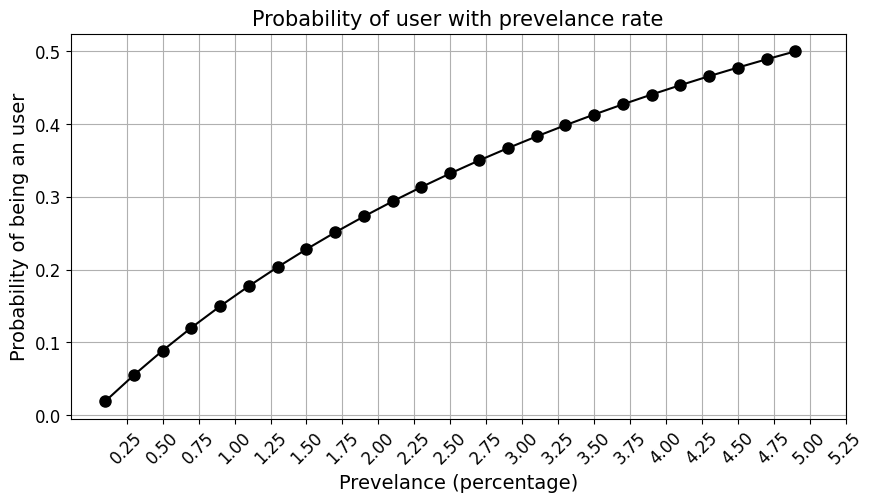

In [36]:
ps = []
pres = []
for pre in [i*0.001 for i in range(1,51,2)]:
    pres.append(pre*100)
    p = drug_user(prob_th=0.5,sensitivity=0.97,specificity=0.95,prevelance=pre,verbose=False)
    ps.append(p)

plt.figure(figsize=(10,5))
plt.title("Probability of user with prevelance rate",fontsize=15)
plt.plot(pres,ps,color='k',marker='o',markersize=8)
plt.grid(True)
plt.xlabel("Prevelance (percentage)",fontsize=14)
plt.ylabel("Probability of being an user",fontsize=14)
plt.xticks([i*0.25 for i in range(1,22)],fontsize=12,rotation=45)
plt.yticks(fontsize=12)
plt.show()

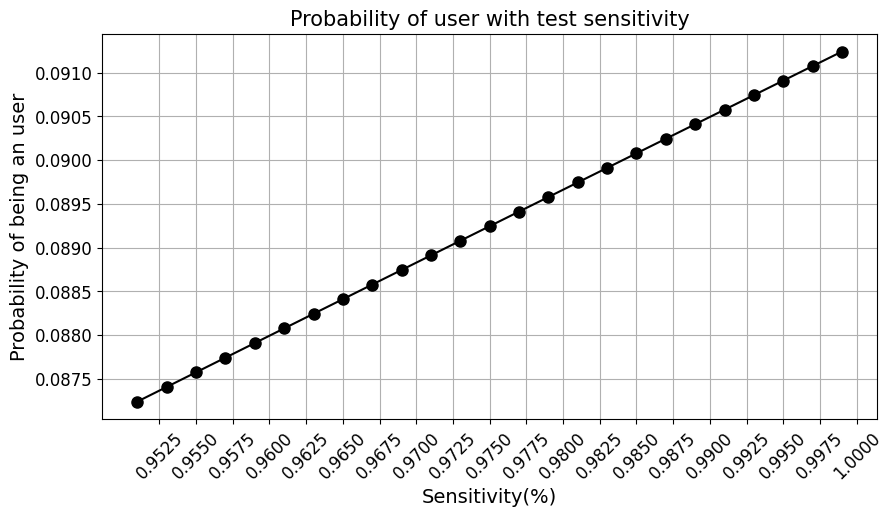

In [37]:
ps = []
sens = []
for sen in [i*0.001+0.95 for i in range(1,50,2)]:
    sens.append(sen)
    p = drug_user(prob_th=0.5,sensitivity=sen,specificity=0.95,prevelance=0.005,verbose=False)
    ps.append(p)

plt.figure(figsize=(10,5))
plt.title("Probability of user with test sensitivity",fontsize=15)
plt.plot(sens,ps,color='k',marker='o',markersize=8)
plt.grid(True)
plt.xlabel("Sensitivity(%)",fontsize=14)
plt.ylabel("Probability of being an user",fontsize=14)
plt.xticks([0.95+i*0.0025 for i in range(1,21)],fontsize=12,rotation=45)
plt.yticks(fontsize=12)
plt.show()

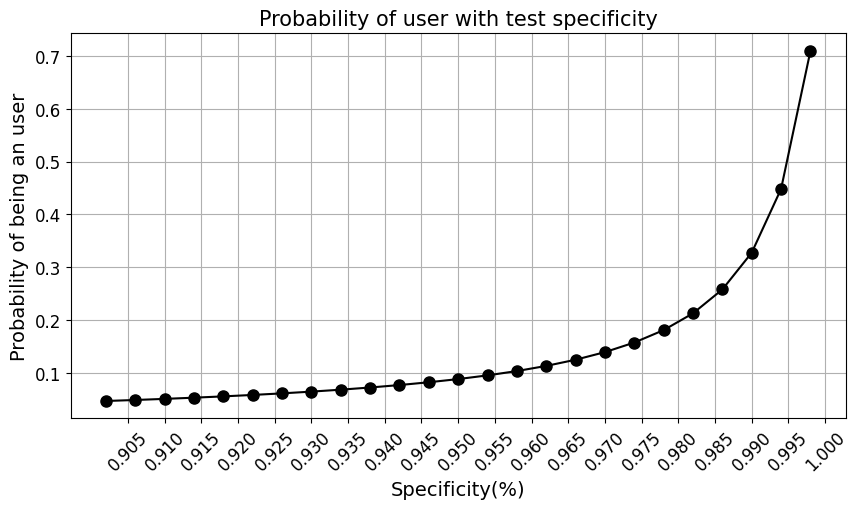

In [38]:
ps = []
spes = []
for spe in [i*0.002+0.9 for i in range(1,50,2)]:
    spes.append(spe)
    p = drug_user(prob_th=0.5,sensitivity=0.97,specificity=spe,prevelance=0.005,verbose=False)
    ps.append(p)

plt.figure(figsize=(10,5))
plt.title("Probability of user with test specificity",fontsize=15)
plt.plot(spes,ps,color='k',marker='o',markersize=8)
plt.grid(True)
plt.xlabel("Specificity(%)",fontsize=14)
plt.ylabel("Probability of being an user",fontsize=14)
plt.xticks([0.9+i*0.005 for i in range(1,21)],fontsize=12,rotation=45)
plt.yticks(fontsize=12)
plt.show()

In [39]:
p1 = drug_user(prob_th=0.5,sensitivity=0.97,specificity=0.95,prevelance=0.005)
print("Probability of the test-taker being a drug user, in the first round of test, is:",round(p1,3))
print()
p2 = drug_user(prob_th=0.5,sensitivity=0.97,specificity=0.95,prevelance=p1)
print("Probability of the test-taker being a drug user, in the second round of test, is:",round(p2,3))
print()
p3 = drug_user(prob_th=0.5,sensitivity=0.97,specificity=0.95,prevelance=p2)
print("Probability of the test-taker being a drug user, in the third round of test, is:",round(p3,3))

Test Negative: Probability of being a drug user is 0.0888 < 0.5
Probability of the test-taker being a drug user, in the first round of test, is: 0.089

Test Positive: Probability of being a drug user is 0.6541 ≥ 0.5
Probability of the test-taker being a drug user, in the second round of test, is: 0.654

Test Positive: Probability of being a drug user is 0.9735 ≥ 0.5
Probability of the test-taker being a drug user, in the third round of test, is: 0.973
